In [ ]:
import sys
from pathlib import Path

import torch
import torch.nn as nn
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurar que la raíz del proyecto esté en PYTHONPATH
root = Path.cwd().resolve()
if not (root / 'src').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.graph_dataset import load_elliptic_graph
from src.gnn_model import GCNClassifier, GATClassifier

# 1. Cargar Datos y Grafo
data, _ = load_elliptic_graph(
    features_path=str(root / 'data' / 'raw' / 'elliptic_txs_features.csv'),
    classes_path=str(root / 'data' / 'raw' / 'elliptic_txs_classes.csv'),
    edgelist_path=str(root / 'data' / 'raw' / 'elliptic_txs_edgelist.csv')
)


Cargando archivos de datos...
Grafo construido con éxito:
   - Nodos (N): 203769
   - Aristas (E): 234355
   - Dimensión de características: 165
   - Etiquetados (Lícitos/Ilícitos): 46564


In [7]:
# 2. Creación de Máscaras Temporales
# Entrenamos solo sobre nodos etiquetados (y != -1)
train_mask = (data.time_step <= 34) & (data.y != -1)
val_mask = (data.time_step >= 35) & (data.time_step <= 41) & (data.y != -1)
test_mask = (data.time_step >= 42) & (data.y != -1)

# Ajuste defensivo por si el split temporal produce muy pocos nodos en validación/test
if val_mask.sum().item() == 0:
    val_mask = (data.time_step >= 35) & (data.time_step <= 45) & (data.y != -1)
if test_mask.sum().item() == 0:
    test_mask = (data.time_step >= 42) & (data.y != -1)

print(f"Nodos Train: {train_mask.sum().item()}")
print(f"Nodos Val:   {val_mask.sum().item()}")
print(f"Nodos Test:  {test_mask.sum().item()}")


Nodos Train: 29894
Nodos Val:   7829
Nodos Test:  8841


In [8]:
# 3. Manejo de Desbalance de Clases (Peso para la clase 1 - Ilícita)
y_train = data.y[train_mask]
num_licit = (y_train == 0).sum().item()
num_illicit = (y_train == 1).sum().item()

if num_illicit == 0:
    raise ValueError('No hay ejemplos ilícitos en el split de entrenamiento; ajusta las máscaras temporales.')

# Peso inversamente proporcional a la frecuencia
pos_weight = torch.tensor([1.0, num_licit / num_illicit], dtype=torch.float32)
print(f"Pesos de Clase (Lícita: {pos_weight[0]:.2f}, Ilícita: {pos_weight[1]:.2f})")


Pesos de Clase (Lícita: 1.00, Ilícita: 7.63)


In [ ]:
# 4. Configurar Modelo, Optimizador y Criterio
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
pos_weight = pos_weight.to(device)

model = GCNClassifier(in_channels=data.num_node_features, hidden_channels=64, out_channels=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=pos_weight)

model_dir = root / 'models'
model_dir.mkdir(exist_ok=True)

best_state = None
best_val_prauc = 0.0
best_epoch = 0
patience = 15
epochs = 150
wait = 0


In [ ]:
# 5. Bucle de Entrenamiento
epochs = 150
patience = 15

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(data.x, data.edge_index)
        probs_val = torch.softmax(out_val[val_mask], dim=1)[:, 1].cpu().numpy()
        y_val_true = data.y[val_mask].cpu().numpy()
        precision, recall, _ = precision_recall_curve(y_val_true, probs_val)
        val_prauc = auc(recall, precision)

    if val_prauc > best_val_prauc + 1e-6:
        best_val_prauc = val_prauc
        best_epoch = epoch
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), model_dir / 'best_gcn_model.pth')
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == epochs:
        print(f"Epoch {epoch:03d} | Loss Train: {loss.item():.4f} | Val PR-AUC: {val_prauc:.4f}")

    if wait >= patience:
        print(f"Early stopping en la época {epoch} por falta de mejora en Val PR-AUC.")
        break


C:\Users\USUARIO\.vscode\Proyectos\elliptic-fraud-detection\src\gnn_model.py:46: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:823.)
  adj = torch.sparse_coo_tensor(


Epoch 010 | Loss Train: 0.5530 | Val PR-AUC: 0.1871
Epoch 020 | Loss Train: 0.4467 | Val PR-AUC: 0.3076
Epoch 030 | Loss Train: 0.3839 | Val PR-AUC: 0.3985
Epoch 040 | Loss Train: 0.3384 | Val PR-AUC: 0.4452
Epoch 050 | Loss Train: 0.3062 | Val PR-AUC: 0.4740
Epoch 060 | Loss Train: 0.2861 | Val PR-AUC: 0.5040



--- RESULTADOS GCN (TEST SET) ---
PR-AUC Test: 0.2683

Reporte de Clasificación:
              precision    recall  f1-score   support

  Lícita (0)       0.99      0.39      0.56      8433
 Ilícita (1)       0.07      0.92      0.13       408

    accuracy                           0.42      8841
   macro avg       0.53      0.66      0.34      8841
weighted avg       0.95      0.42      0.54      8841



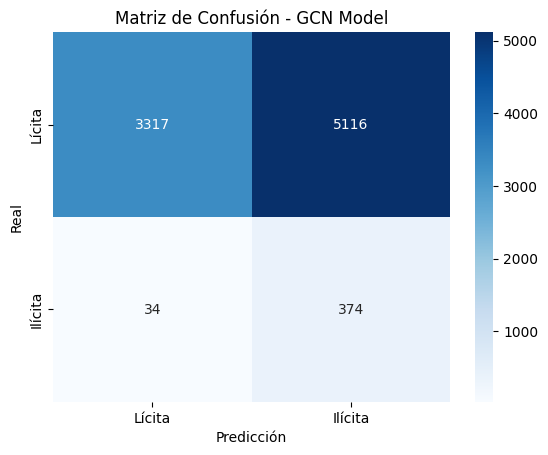

In [ ]:
# 6. Evaluación Final en el Test Set (Pasos Temporales 42-49)
model.load_state_dict(torch.load(model_dir / 'best_gcn_model.pth', map_location=device))
model.eval()

with torch.no_grad():
    logits_test = model(data.x, data.edge_index)[test_mask]
    probs_test = torch.softmax(logits_test, dim=1)[:, 1].cpu().numpy()
    y_test_true = data.y[test_mask].cpu().numpy()

# Métricas con umbral por defecto (0.5)
default_preds = (probs_test >= 0.5).astype(int)
precision_default, recall_default, _ = precision_recall_curve(y_test_true, probs_test)
test_prauc = auc(recall_default, precision_default)
print("\n--- RESULTADOS GCN (TEST SET) ---")
print(f"PR-AUC Test: {test_prauc:.4f}")
print("\n[Umbral por defecto = 0.5]")
print(classification_report(y_test_true, default_preds, target_names=['Lícita (0)', 'Ilícita (1)']))

# Búsqueda del umbral óptimo en validación
val_probs = torch.softmax(model(data.x, data.edge_index)[val_mask], dim=1)[:, 1].cpu().numpy()
y_val_true = data.y[val_mask].cpu().numpy()

best_threshold = 0.5
best_f1 = 0.0
for threshold in [t / 10 for t in range(1, 10)]:
    preds_val = (val_probs >= threshold).astype(int)
    report = classification_report(y_val_true, preds_val, output_dict=True, zero_division=0)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Umbral óptimo encontrado en validación: {best_threshold:.2f} con F1 = {best_f1:.4f}")

# Evaluación con umbral óptimo en test
optimized_preds = (probs_test >= best_threshold).astype(int)
print("\n[Umbral optimizado en validación]")
print(classification_report(y_test_true, optimized_preds, target_names=['Lícita (0)', 'Ilícita (1)']))

# Matrices de Confusión
cm_default = confusion_matrix(y_test_true, default_preds)
cm_opt = confusion_matrix(y_test_true, optimized_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', xticklabels=['Lícita', 'Ilícita'], yticklabels=['Lícita', 'Ilícita'], ax=axes[0])
axes[0].set_title('Default threshold 0.5')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', xticklabels=['Lícita', 'Ilícita'], yticklabels=['Lícita', 'Ilícita'], ax=axes[1])
axes[1].set_title(f'Optimized threshold {best_threshold:.2f}')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()
